In [ ]:
import numpy as np          #importing all the necessary libraries for data manipulation, visualization, model building and evaluation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

import joblib


In [ ]:
df = pd.read_csv("diabetes.csv")  #loading the diabetes dataset into a pandas DataFrame
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Replace invalid zeros with NaN for specific columns
cols_to_fix = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

#  missing values
imputer = SimpleImputer(strategy="median")
df[cols_to_fix] = imputer.fit_transform(df[cols_to_fix])

df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
Q1 = df.quantile(0.25)   #removing outliers
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
df.shape


(375, 9)

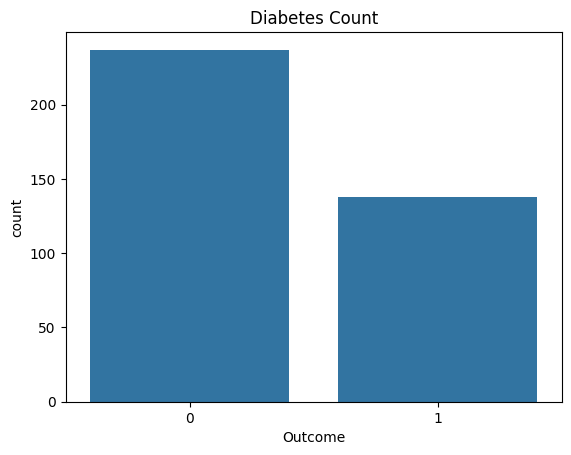

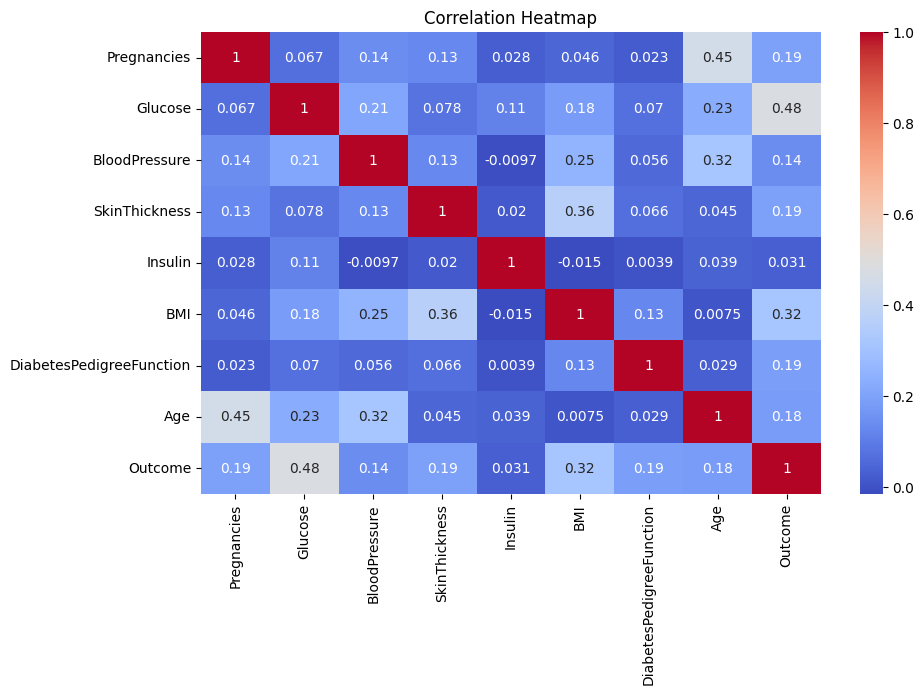

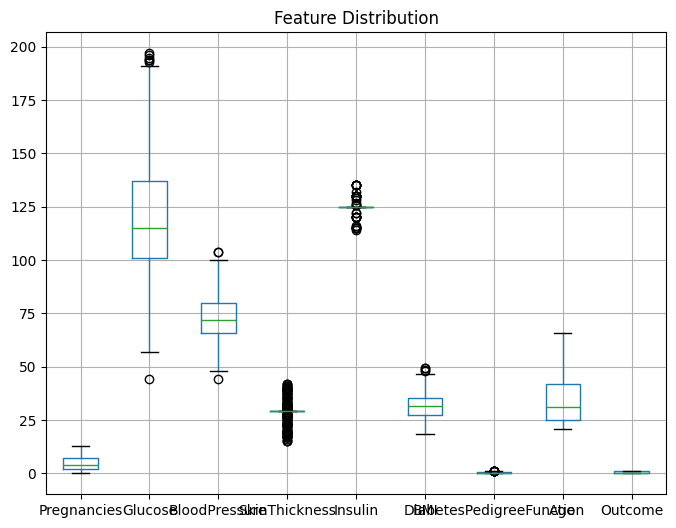

In [21]:
# Outcome distribution
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Count")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplot
df.boxplot(figsize=(8,6))
plt.title("Feature Distribution")
plt.show()


In [22]:
# Select features based on correlation
corr = df.corr()["Outcome"].abs().sort_values(ascending=False)
selected_features = corr[1:7].index.tolist()  # top 6 features

print("Selected Features:", selected_features)

X = df[selected_features]
y = df["Outcome"]


Selected Features: ['Glucose', 'BMI', 'Pregnancies', 'SkinThickness', 'DiabetesPedigreeFunction', 'Age']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [24]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier()
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 0.7467
Random Forest Accuracy: 0.7200


In [25]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)


Best Model: Logistic Regression


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80        46
           1       0.69      0.62      0.65        29

    accuracy                           0.75        75
   macro avg       0.73      0.72      0.73        75
weighted avg       0.74      0.75      0.74        75



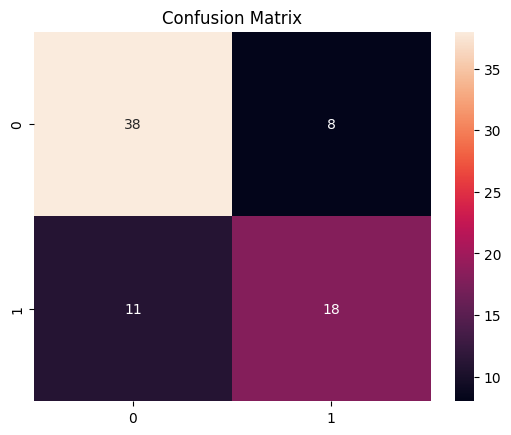

In [26]:
y_pred = best_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()


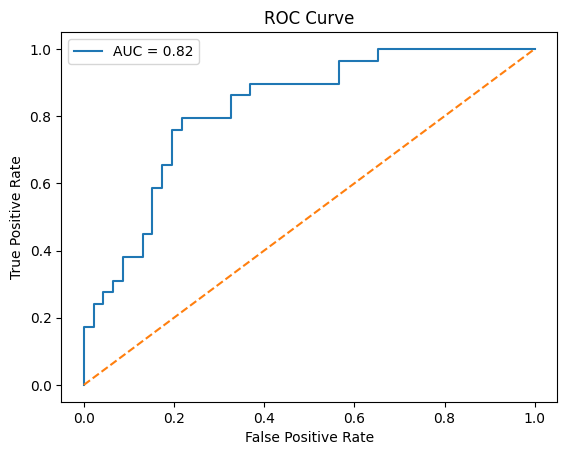

In [27]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [31]:
joblib.dump(best_model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selected_features, "features.pkl")


['features.pkl']